In [2]:
# Read and Plot individual seismic shots from KOPRI
# Zachary Katz
# 20 October 2025

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from obspy.io.segy.core import _read_segy
import os

file_path = './_data/KPDC_David_Seismic_2022/RAW/21X.sgy'
#file_path = './_data/KPDC_David_Seismic_2022/PSTM/D2SL2122_PSTM_Stack_Time_domain_static_aperture400_YY2.sgy'
seismogram = _read_segy(file_path, unpack_trace_headers=True)

In [151]:
# File load
sgy_file = './_data/KPDC_David_Seismic_2022/RAW/21YY'
sgy_path = sgy_file + '.sgy'
fldr_number = 2  # Feild record number

figures_dir = 'Figures'

# 폴더가 존재하지 않으면 생성
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)
    print(f"폴더 생성됨: {figures_dir}")
else:
    print(f"폴더 이미 존재함: {figures_dir}")

폴더 이미 존재함: Figures


In [152]:
from obspy.io.segy.core import _read_segy

def segyload_obspy(sgy_path, fldr_number=1):
    # Load entire SEG-Y file
    st = _read_segy(sgy_path, unpack_trace_headers=True)

    # Sampling values
    dt = st[0].stats.delta          # seconds
    ns = st[0].stats.npts
    time = np.arange(ns) * dt       # seconds

    # Select traces based on Field Record Number (fldr)
    selected_traces = []
    coords = {'source_x': [], 'source_y': [], 'group_x': [], 'group_y': []}
    for tr in st:
        hdr = tr.stats.segy.trace_header
        if hdr.original_field_record_number == fldr_number:
            selected_traces.append(tr.data)
            coords['source_x'].append(hdr.source_coordinate_x)
            coords['source_y'].append(hdr.source_coordinate_y)
            coords['group_x'].append(hdr.group_coordinate_x)
            coords['group_y'].append(hdr.group_coordinate_y)

    if len(selected_traces) == 0:
        raise ValueError(f"No traces found for fldr={fldr_number}")

    data = np.stack(selected_traces)
    n_traces = data.shape[0]

    print(f"Selected {n_traces} traces for fldr={fldr_number}")

    # Percentile clipping
    #lower_clip = np.percentile(data, 0.05)
    #upper_clip = np.percentile(data, 99.95)
    #data_clipped = np.clip(data, lower_clip, upper_clip)
    data_clipped = data
    # Transpose to (ns, n_traces) like segyio version
    data_clipped = data_clipped.T

    return data_clipped, time, n_traces, coords


In [153]:
data_clipped, time, n_traces, coords = segyload_obspy(sgy_path, fldr_number)


Selected 96 traces for fldr=2


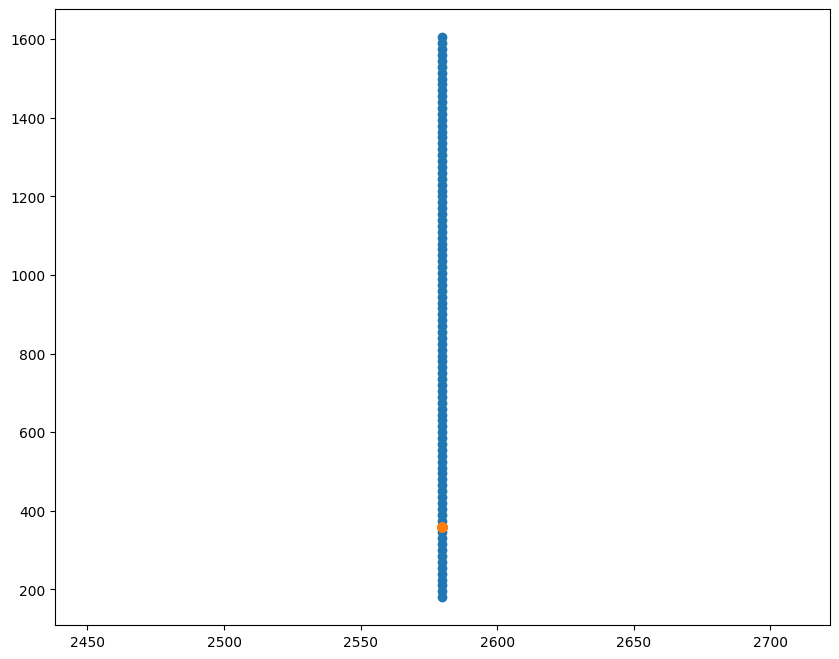

In [154]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(coords['group_x'], coords['group_y'])
ax.scatter(coords['source_x'], coords['source_y'])

In [155]:
z = 2250 # Assume constant depth
dist = np.array([np.sqrt((coords['group_x'][i]-coords['source_x'][i])**2 + (coords['group_y'][i]-coords['source_y'][i])**2 ) for i in range(len(coords['group_x']))])
offset_angle = np.rad2deg(np.arctan2(dist/2, z))
offset_angle


array([ 2.29061004,  2.09990452,  1.90915243,  1.718358  ,  1.52752544,
        1.33665898,  1.14576284,  0.95484125,  0.76389846,  0.5729387 ,
        0.3819662 ,  0.19098522,  0.        ,  0.19098522,  0.3819662 ,
        0.5729387 ,  0.76389846,  0.95484125,  1.14576284,  1.33665898,
        1.52752544,  1.718358  ,  1.90915243,  2.09990452,  2.29061004,
        2.4812648 ,  2.67186459,  2.86240523,  3.05288251,  3.24329228,
        3.43363036,  3.6238926 ,  3.81407483,  4.00417294,  4.19418279,
        4.38410026,  4.57392126,  4.76364169,  4.95325748,  5.14276456,
        5.33215888,  5.52143641,  5.71059314,  5.89962505,  6.08852815,
        6.27729849,  6.4659321 ,  6.65442505,  6.84277341,  7.0309733 ,
        7.21902082,  7.40691213,  7.59464337,  7.78221072,  7.96961039,
        8.1568386 ,  8.34389158,  8.53076561,  8.71745696,  8.90396196,
        9.09027692,  9.27639821,  9.46232221,  9.64804532,  9.83356396,
       10.01887461, 10.20397372, 10.38885782, 10.57352342, 10.75

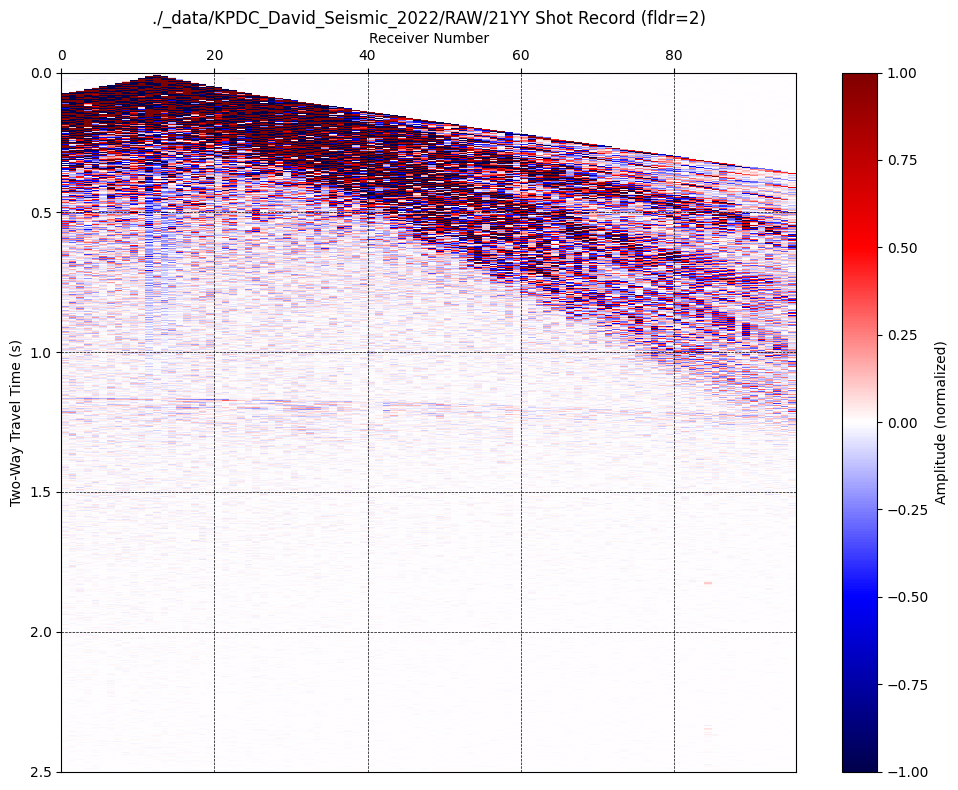

In [156]:
# Plot variable density image
fig, ax = plt.subplots(figsize=(10, 8))
extent = [0, n_traces, time[-1], time[0]]
im = ax.imshow(data_clipped,
               cmap='seismic',
               interpolation='none', # 'gaussian' to get image that looks like Ju's
               aspect='auto',
               extent=extent,
               vmin=-1, vmax=1)

# 범위 제한
ax.set_xlim(0, 96)         # x축: trace 1번 ~ 96번
ax.set_ylim(2.5, 0)        # y축: 0 ~ 2.5초

# 수신기 점선 (20개 간격)
recive_grid = np.arange(0, 96, 20)
for t in recive_grid:
    ax.axvline(x=t, color='black', linestyle='--', linewidth=0.5)

# 시간축 점선 (0.1초 간격)
time_grid = np.arange(0, 2.5, 0.5)
for t in time_grid:
    ax.axhline(y=t, color='black', linestyle='--', linewidth=0.5)

# Labeling
ax.set_title(f"{sgy_file} Shot Record (fldr={fldr_number})")
ax.set_xlabel("Receiver Number")
ax.set_ylabel("Two-Way Travel Time (s)")

# x축 라벨과 눈금을 상단으로
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Amplitude (normalized)')

plt.tight_layout()
plt.show()

# export the figure
#fig.savefig(f"{figures_dir}/{sgy_file}_raw_data_gather_fldr{fldr_number}.pdf",
#            dpi=300, bbox_inches='tight')
#plt.close(fig)

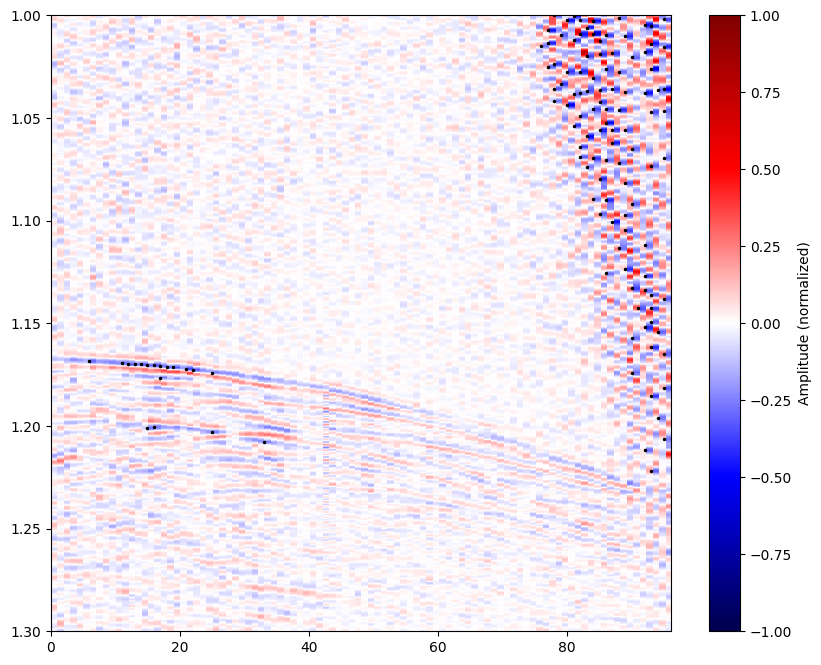

In [159]:
# For trace in the 96 traces, get the amplitude of the first reflection
from scipy.signal import find_peaks

fig, ax = plt.subplots(figsize=(10, 8))
st_time = 1
et_time = 1.3

# slice indices
i1 = np.searchsorted(time, st_time)
i2 = np.searchsorted(time, et_time)

data_win = data_clipped[i1:i2, :]
time_win = time[i1:i2]

extent = [0, n_traces, time_win[-1], time_win[0]]

im = ax.imshow(
    data_win,
    cmap='seismic',
    interpolation='none',
    aspect='auto',
    extent=extent,
    vmin=-1, vmax=1
)

ax.set_xlim(0, n_traces)       # traces 0..N
ax.set_ylim(et_time, st_time)  # flip time axis (deeper at bottom)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Amplitude (normalized)')


peak_indices_per_trace = []
peak_props_per_trace = []
first_peak_amp = np.full(data_clipped.shape[1], np.nan)   # default if no peak

for trace_idx in range(data_clipped.shape[1]):
    trace = data_clipped[:, trace_idx]
    trace = -trace

    # Find peaks — add parameters as needed (height, distance, prominence…)
    peaks, props = find_peaks(trace, prominence=0.1, distance=10, height=0.25)

    if len(peaks) > 0:
        first_idx = peaks[0]          # earliest (shallowest) peak
        first_peak_amp[trace_idx] = -trace[first_idx] # Looking at minima still

    peak_indices_per_trace.append(peaks)
    peak_props_per_trace.append(props)

peak_times = [time[peaks] for peaks in peak_indices_per_trace]

for tr, peaks in enumerate(peak_indices_per_trace):
    ax.plot([tr]*len(peaks), time[peaks], 'k.', markersize=3)




In [145]:
# Make theoretical AVO curves
def Aki_Richards_ZoeppritzApprox(angles, p1, p2, s1, s2, rho1, rho2):
    thetas = np.deg2rad(angles)
    p = (p1 + p2) / 2
    delta_p = p2 - p1
    s = (s1 + s2) / 2
    delta_s = s2 - s1
    rho = (rho1 + rho2) / 2
    delta_rho = rho2 - rho1

    term1 = 0.5 * ( 1 + np.tan(thetas)*np.tan(thetas)) * delta_p / p
    term2 = (4 * (s*s) / (p * p) * np.sin(thetas) * np.sin(thetas) * delta_s / s)
    term3 = 0.5 * ( 1 -4 * (s*s) / (p * p) * np.sin(thetas) * np.sin(thetas))* delta_rho / rho

    return term1 - term2 + term3

def Shuey_ZoeppritzApprox(angles, p1, p2, s1, s2, rho1, rho2):
    
    thetas = np.deg2rad(angles)
    p = (p1 + p2) / 2
    delta_p = p2 - p1
    s = (s1 + s2) / 2
    delta_s = s2 - s1
    rho = (rho1 + rho2) / 2
    delta_rho = rho2 - rho1
    
    R0 = 0.5 * (delta_p / p + delta_rho / rho)
    k = (s / p) ** 2
    G = 0.5 * (delta_p / p) - 2.0 * k * (delta_rho / rho + 2.0 * delta_s / s)
    F = 0.5 * (delta_p / p)
    R = R0 + G * np.sin(thetas)**2 + F * (np.tan(thetas)**2 - np.sin(thetas)**2)
    return R

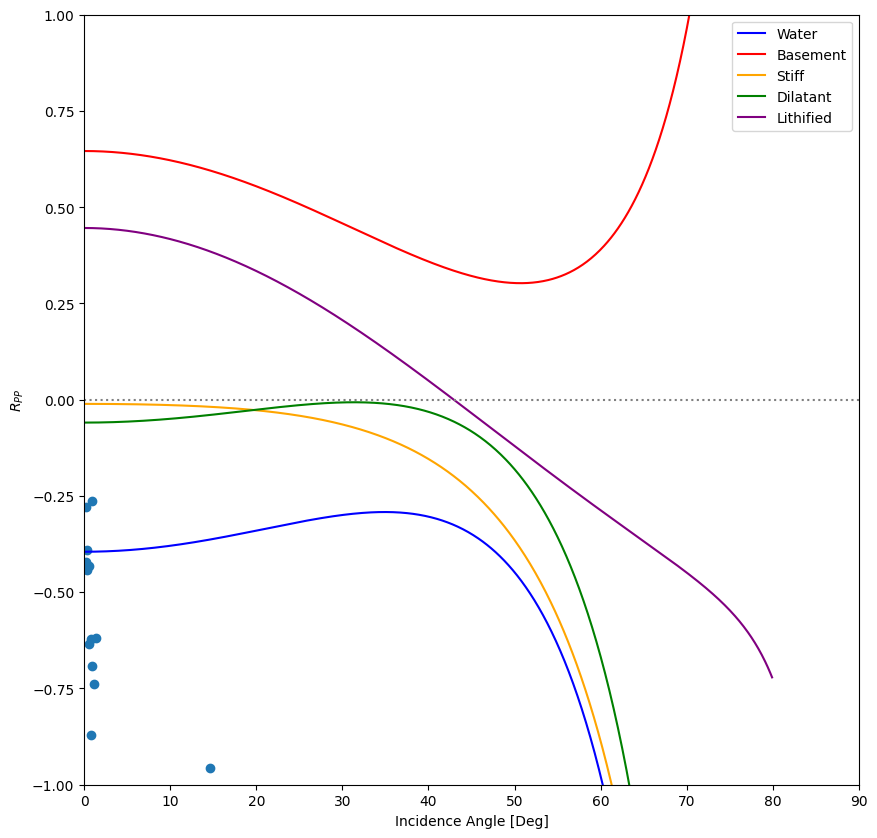

In [146]:
angles = np.arange(0, 80, 0.1)

# Ice
alpha_Ice = 3810
beta_Ice = 1860
rho_Ice =  920

materials = {
    "Water": {
        "alpha": 1500,
        "beta": 0,
        "rho": 997,
    },
    "Basement": {
        "alpha": 5200,
        "beta": 2800,
        "rho": 2700,
    },
    "Stiff": {
        "alpha": 1800,
        "beta": 1000,
        "rho": 1900,
    },
    "Dilatant": {
        "alpha": 1700,
        "beta": 200,
        "rho": 1800,
    },
    "Lithified": {
        "alpha": 3750,
        "beta": 2450,
        "rho": 2450,
    },
}

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['blue', 'red', 'orange','green', 'purple']
for color, (name, props) in zip(colors, materials.items()):
    #R = Aki_Richards_ZoeppritzApprox(angles, alpha_Ice, props['alpha'], beta_Ice, props['beta'], rho_Ice, props['rho'])
    R = Shuey_ZoeppritzApprox(angles, alpha_Ice, props['alpha'], beta_Ice, props['beta'], rho_Ice, props['rho'])
    ax.plot(angles, R, color=color, label=name)
    ax.legend()
ax.set_ylim(-1,1)
ax.set_xlim(0,90)
ax.axhline(0, color='gray', linestyle=':')
ax.set_ylabel(r'$R_{PP}$')
ax.set_xlabel('Incidence Angle [Deg]')

ax.scatter(offset_angle, first_peak_amp)


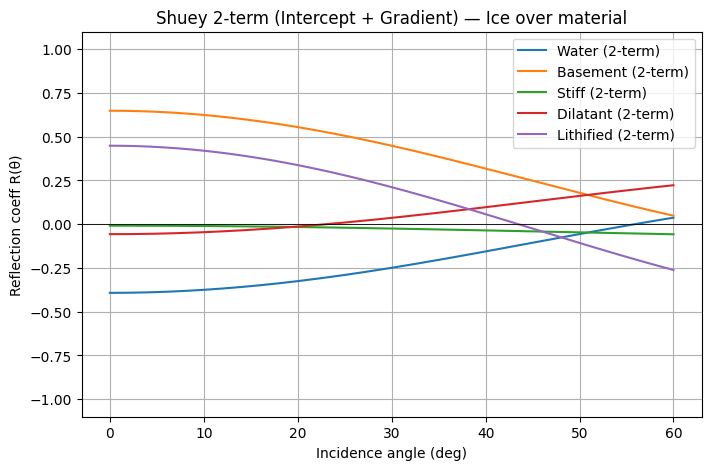

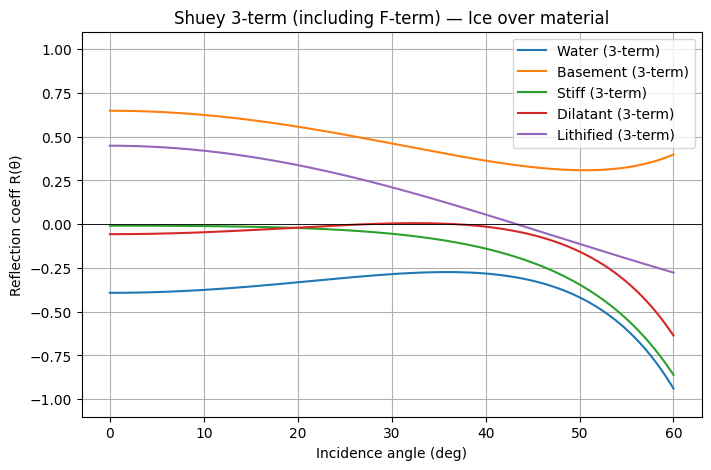

In [ ]:
# FROM CHATGPT
import numpy as np
import matplotlib.pyplot as plt

def shuey(angles_deg, vp1, vp2, vs1, vs2, rho1, rho2, wide_angle=False):
    """
    Shuey approximation for reflection coefficient R(theta).
    angles_deg : array-like angles in degrees
    vp1,vp2 : P-wave velocities (m/s)
    vs1,vs2 : S-wave velocities (m/s)  (may be 0 for fluids)
    rho1,rho2 : densities (kg/m^3 or g/cc consistent units)
    wide_angle : if True include 3-term (F-term). If False, return 2-term Shuey.
    """
    theta = np.deg2rad(np.asarray(angles_deg))
    # Averages and contrasts
    vp = 0.5 * (vp1 + vp2)
    vs = 0.5 * (vs1 + vs2)
    rho = 0.5 * (rho1 + rho2)

    dvp = vp2 - vp1
    dvs = vs2 - vs1
    drho = rho2 - rho1

    # Avoid divide-by-zero when vs==0 (fluid). Use safe dvs_over_vs.
    if vs > 0:
        dvs_over_vs = dvs / vs
    else:
        dvs_over_vs = 0.0

    # k = (Vs/Vp)^2 (set to zero safely for fluids)
    k = (vs / vp) ** 2 if vp != 0 and vs > 0 else 0.0

    # Shuey terms
    R0 = 0.5 * (dvp / vp + drho / rho)          # intercept
    # gradient term; if vs==0 the second portion (with k) becomes zero automatically
    G = 0.5 * (dvp / vp) - 2.0 * k * (drho / rho + 2.0 * dvs_over_vs)

    if wide_angle:
        F = 0.5 * (dvp / vp)
        R = R0 + G * np.sin(theta)**2 + F * (np.tan(theta)**2 - np.sin(theta)**2)
    else:
        R = R0 + G * np.sin(theta)**2

    return R

# --- Your material definitions (from conversation) ---
alpha_Ice = 3800.0
beta_Ice  = 1900.0
rho_Ice   = 917.0

# Angles to plot
angles = np.linspace(0, 60, 301)   # 0..60 degrees

# Plot 2-term Shuey
plt.figure(figsize=(8,5))
for name, props in materials.items():
    R = shuey(angles,
              alpha_Ice, props["alpha"],
              beta_Ice,  props["beta"],
              rho_Ice,   props["rho"],
              wide_angle=False)
    plt.plot(angles, R, label=f"{name} (2-term)")

plt.axhline(0, color='k', linewidth=0.6)
plt.xlabel("Incidence angle (deg)")
plt.ylabel("Reflection coeff R(θ)")
plt.title("Shuey 2-term (Intercept + Gradient) — Ice over material")
plt.legend()
plt.grid(True)
plt.ylim(-1.1, 1.1)
plt.show()

# Plot 3-term Shuey (wide-angle)
plt.figure(figsize=(8,5))
for name, props in materials.items():
    R3 = shuey(angles,
               alpha_Ice, props["alpha"],
               beta_Ice,  props["beta"],
               rho_Ice,   props["rho"],
               wide_angle=True)
    plt.plot(angles, R3, label=f"{name} (3-term)")

plt.axhline(0, color='k', linewidth=0.6)
plt.xlabel("Incidence angle (deg)")
plt.ylabel("Reflection coeff R(θ)")
plt.title("Shuey 3-term (including F-term) — Ice over material")
plt.legend()
plt.grid(True)
plt.ylim(-1.1, 1.1)
plt.show()


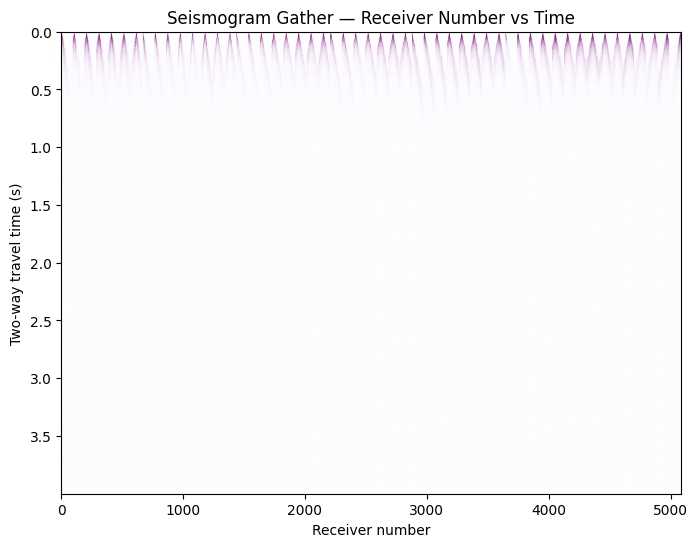

In [3]:
import numpy as np
import matplotlib.pyplot as plt

traces = seismogram.traces

# coordinate scalar from SEG-Y (sometimes negative means divide)
scalar = traces[0].stats.segy.trace_header.scalar_to_be_applied_to_all_coordinates
if scalar < 0:
    coord_scale = 1 / abs(scalar)
else:
    coord_scale = scalar

# source coordinate
src_x = traces[0].stats.segy.trace_header.source_coordinate_x * coord_scale
src_y = traces[0].stats.segy.trace_header.source_coordinate_y * coord_scale

# receiver coordinates
rec_x = np.array([tr.stats.segy.trace_header.group_coordinate_x for tr in traces]) * coord_scale
rec_y = np.array([tr.stats.segy.trace_header.group_coordinate_y for tr in traces]) * coord_scale

# ---- FIX HERE ----
# if coordinates look too small (e.g., offset < 500 m total), scale up by 1000
if np.max(np.abs(rec_x - src_x)) < 500:
    rec_x *= 1000
    rec_y *= 1000

# compute offset (m)
offset = np.sqrt((rec_x - src_x)**2 + (rec_y - src_y)**2)

# time axis
dt = traces[0].stats.delta  # in seconds
nt = traces[0].stats.npts
time = np.arange(nt) * dt

# plot wiggles or image
data = np.array([tr.data for tr in traces]).T

plt.figure(figsize=(8,6))
plt.imshow(data, aspect='auto', extent=[0, len(traces), time[-1], time[0]], cmap='seismic')
plt.xlabel("Receiver number")
plt.ylabel("Two-way travel time (s)")
plt.title("Seismogram Gather — Receiver Number vs Time")
plt.show()


In [4]:
USEC_TO_SEC = 1e-6
source_x = np.array([sgram.stats.segy.trace_header.source_coordinate_x for sgram in seismogram.traces])
source_y = np.array([sgram.stats.segy.trace_header.source_coordinate_y for sgram in seismogram.traces])
rec_x = np.array([sgram.stats.segy.trace_header.group_coordinate_x for sgram in seismogram.traces])
rec_y = np.array([sgram.stats.segy.trace_header.group_coordinate_y for sgram in seismogram.traces])
n = np.array([sgram.stats.segy.trace_header.number_of_samples_in_this_trace for sgram in seismogram.traces])
dt = np.array([sgram.stats.segy.trace_header.sample_interval_in_ms_for_this_trace * USEC_TO_SEC for sgram in seismogram.traces])

# Check same sample rate and number of samples for all traces
assert all(d == dt[0] for d in dt)
assert all(i == n[0] for i in n)

time = np.arange(n[0]) * dt[0]

In [5]:

offsets = []
for tr in seismogram.traces:
    hdr = tr.stats.segy.trace_header
    dx = hdr.group_coordinate_x - hdr.source_coordinate_x
    dy = hdr.group_coordinate_y - hdr.source_coordinate_y
    #offsets.append(tr.data[:10])
    offsets.append(np.sqrt(dx**2 + dy**2))
    
print(offsets[:])

[np.float64(90.0), np.float64(75.0), np.float64(60.0), np.float64(45.0), np.float64(30.0), np.float64(15.0), np.float64(0.0), np.float64(15.0), np.float64(30.0), np.float64(45.0), np.float64(60.0), np.float64(75.0), np.float64(90.0), np.float64(105.0), np.float64(120.0), np.float64(135.0), np.float64(150.0), np.float64(165.0), np.float64(180.0), np.float64(195.0), np.float64(210.0), np.float64(225.0), np.float64(240.0), np.float64(255.0), np.float64(270.0), np.float64(285.0), np.float64(300.0), np.float64(315.0), np.float64(330.0), np.float64(345.0), np.float64(360.0), np.float64(375.0), np.float64(390.0), np.float64(405.0), np.float64(420.0), np.float64(435.0), np.float64(450.0), np.float64(465.0), np.float64(480.0), np.float64(495.0), np.float64(510.0), np.float64(525.0), np.float64(540.0), np.float64(555.0), np.float64(570.0), np.float64(585.0), np.float64(600.0), np.float64(615.0), np.float64(630.0), np.float64(645.0), np.float64(660.0), np.float64(675.0), np.float64(690.0), np.flo

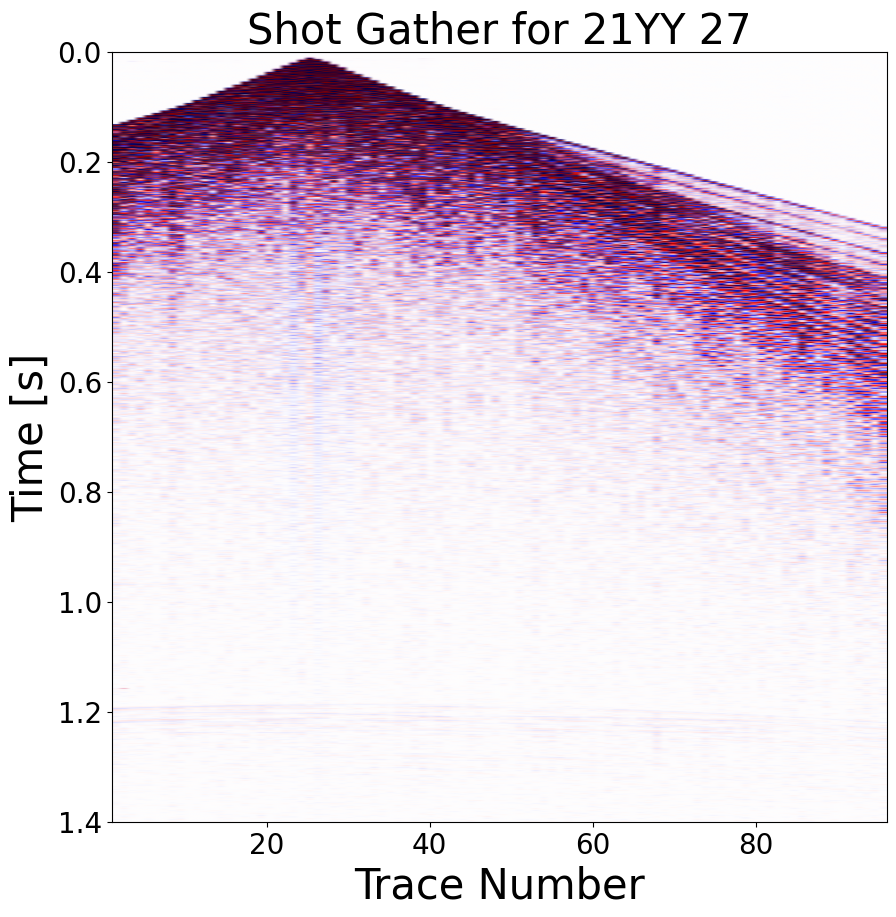

In [8]:
# Plot a single shot gather
shot_id = 27
n_traces = 96 #*10
start = (shot_id - 1) * n_traces
end = start + n_traces
data = np.column_stack([tr.data for tr in seismogram.traces[start:end]])
data /= np.abs(data).max()
rec_nums = np.arange(1, n_traces + 1)

fig, ax = plt.subplots(figsize=(10, 10))
extent = [rec_nums[0], rec_nums[-1], time[-1], time[0]]  # flip Y so time increases downward, divide by 2 to get two way trave time
im = ax.imshow(data, cmap="seismic", aspect="auto", extent=extent, vmin=-0.04, vmax=0.04)

ax.set_ylim(1.4, 0)
ax.set_xlabel("Trace Number",size=30)
ax.set_ylabel("Time [s]",size=30)
ax.set_title(f"Shot Gather for 21YY {shot_id}",size=30)
# Set xtick and ytick font size
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

In [141]:
for i, tr in enumerate(seismogram.traces[:5]):
    hdr = tr.stats.segy.trace_header
    print(i, hdr.group_coordinate_x, hdr.source_coordinate_x)

0 0 25800
1 0 25800
2 0 25800
3 0 25800
4 0 25800


Text(0.5, 1.0, 'D2SL2122_PSTM_Stack_Time_domain_static_aperture400_YY2.sgy')

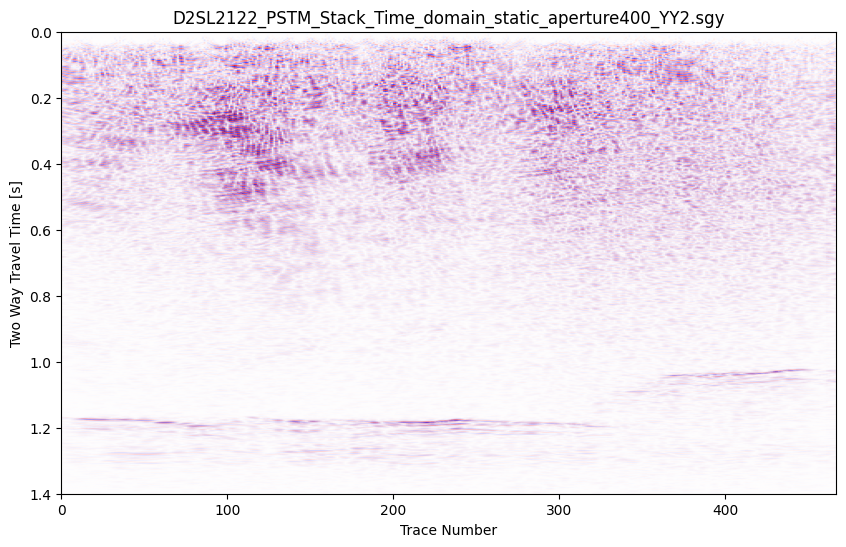

In [144]:
t = np.arange(n[0]) * dt[0]

arr = np.stack([sgram.data for sgram in seismogram.traces])
arr /= np.abs(arr).max()
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(
arr.T,
extent=[0, len(arr), max(t), min(t)],  # map array indices to coords & time
aspect="auto",
cmap="seismic",
vmin = -1,
vmax = 1,
)
ax.set_xlabel("Trace Number")
ax.set_ylabel("Two Way Travel Time [s]")
ax.set_ylim(1.4, 0)
ax.set_title("D2SL2122_PSTM_Stack_Time_domain_static_aperture400_YY2.sgy")

In [28]:
np.unique(arr)

array([-72.872955, -71.33273 , -68.95653 , ...,  48.265152,  51.559967,
        53.164078], shape=(1712121,), dtype=float32)